# 03 — Model comparison

This project uses synthetic data inspired by common online gaming analytics use cases. It does not contain confidential or proprietary Junglee Games data.

The full search ran in `src/train.py` (stratified cross-validation on an April subsample, refit on all April rows, threshold tuned on May, metrics on June). This notebook recomputes the holdout metrics from the saved probabilities so the table is not a pasted number.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import os
os.chdir(ROOT)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Project root:", ROOT)


Project root: /workspace/player-churn-prediction


In [2]:
from src.evaluation import classification_metrics

metrics = json.loads((ROOT / "reports/model_metrics/metrics.json").read_text())
preds = pd.read_csv(ROOT / "reports/model_metrics/test_predictions.csv")
rows = []
for record in metrics["comparison"]:
    name = record["model"]
    recomputed = classification_metrics(preds["y_true"].to_numpy(), preds[f"p_{name}"].to_numpy(), record["threshold"])
    rows.append({
        "Model": name,
        "Accuracy": recomputed["accuracy"],
        "Precision": recomputed["precision"],
        "Recall": recomputed["recall"],
        "F1": recomputed["f1"],
        "ROC-AUC": recomputed["roc_auc"],
        "PR-AUC": recomputed["pr_auc"],
        "Threshold": record["threshold"],
        "May PR-AUC": record["validation_pr_auc"],
    })
table = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
display(table)
display(Markdown(
    f"Champion **{metrics['champion']}** was selected on May PR-AUC, not on June accuracy. "
    "Selecting on the test month would leak the holdout into the choice."
))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Threshold,May PR-AUC
0,random_forest,0.6532,0.3536,0.7278,0.4760,0.7206,0.3719,0.4600,0.6477
1,logistic_regression,0.6422,0.3451,0.7276,0.4681,0.7158,0.3674,0.6400,0.5289
2,xgboost,0.6576,0.3538,0.7047,0.4711,0.7124,0.3669,0.5300,0.6331
3,hist_gradient_boosting,0.6547,0.3529,0.7147,0.4725,0.7167,0.3667,0.5300,0.6293
4,lightgbm,0.6564,0.3529,0.7047,0.4703,0.7158,0.3661,0.5300,0.6351
5,gradient_boosting,0.6544,0.3540,0.7240,0.4755,0.7160,0.3607,0.5600,0.6277


Champion **random_forest** was selected on May PR-AUC, not on June accuracy. Selecting on the test month would leak the holdout into the choice.

June base rate 21.6%. Calling everyone retained would post accuracy 78.4% and catch no churners. The comparison table's accuracy column is therefore a poor referee.

On the champion, a **false positive** is one of the 20,488 players flagged who still played in the next 30 days — a contact, and possibly an incentive, spent on someone who was staying. A **false negative** is one of the 4,191 churners the threshold did not flag. The desk's cost ratio decides which error is more expensive. Beta 1.5 on the May threshold leans toward catching churners, and it is a policy choice, not a law.

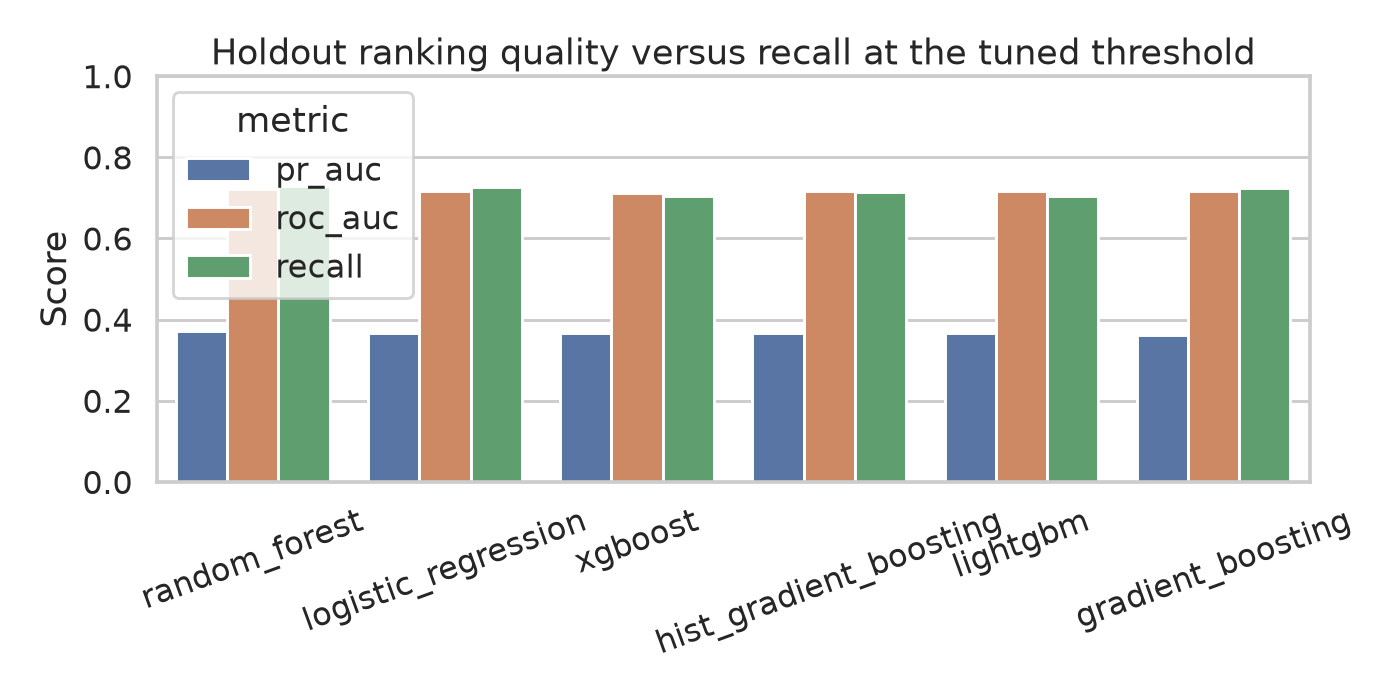

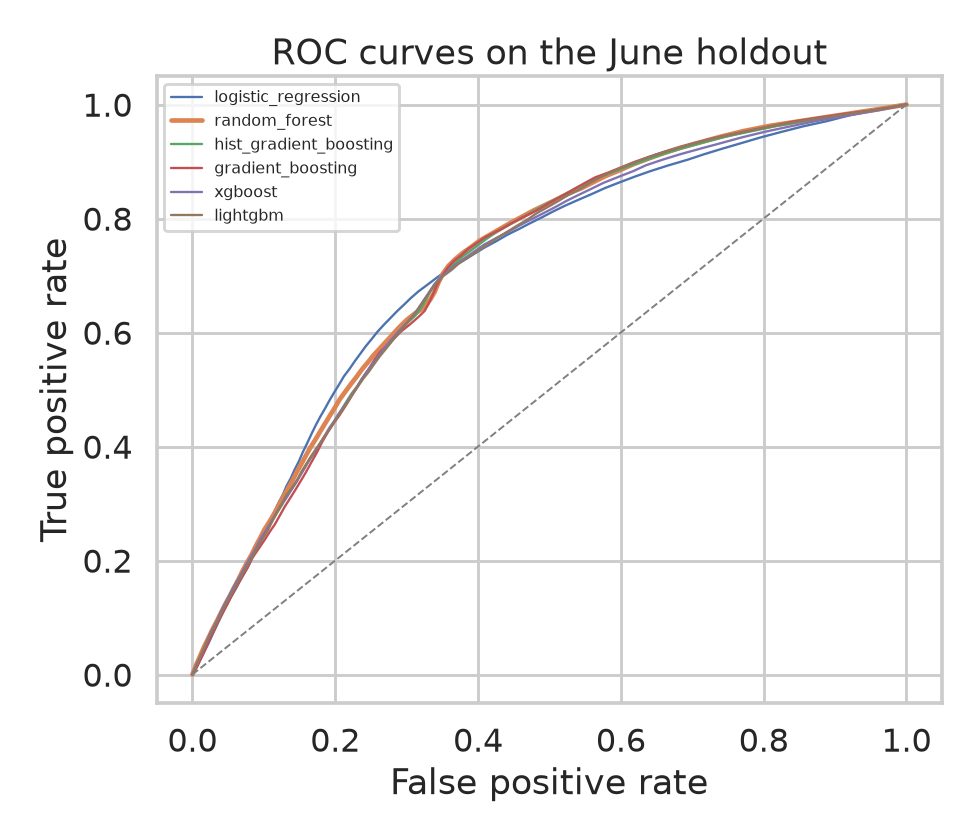

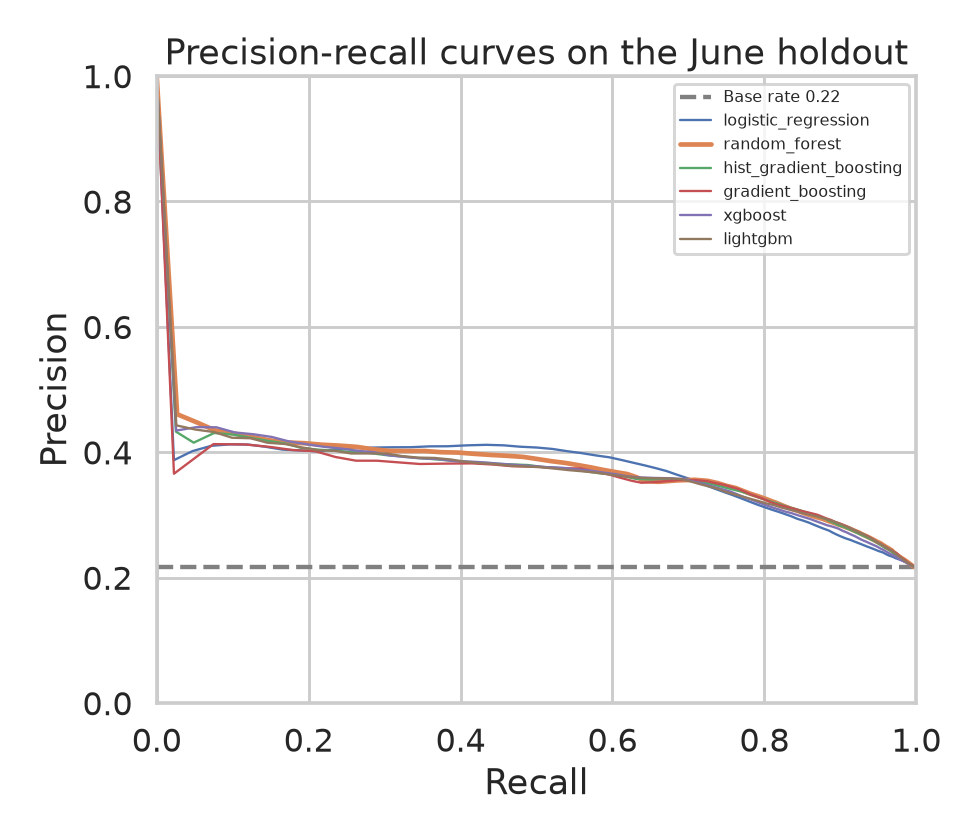

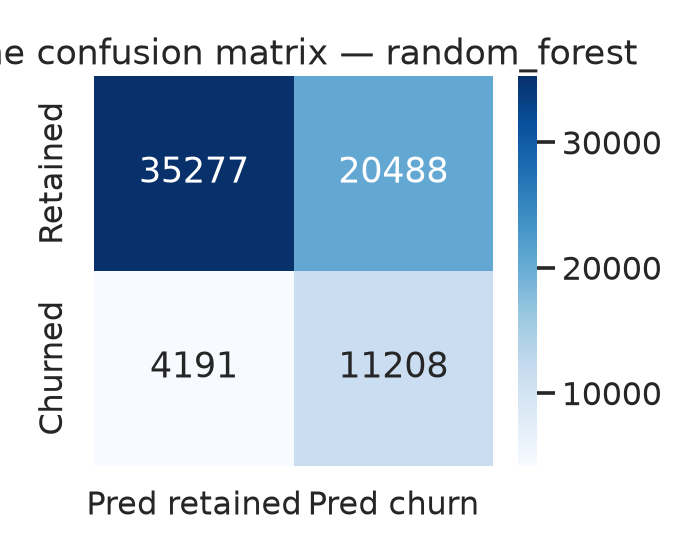

In [3]:
base = float(preds["y_true"].mean())
display(Markdown(
    f"June base rate {base:.1%}. Calling everyone retained would post accuracy {1-base:.1%} "
    "and catch no churners. The comparison table's accuracy column is therefore a poor referee."
))
champ = metrics["champion_test"]["confusion_matrix"]
display(Markdown(
    f"On the champion, a **false positive** is one of the {champ['fp']:,} players flagged who still played "
    f"in the next 30 days — a contact, and possibly an incentive, spent on someone who was staying. "
    f"A **false negative** is one of the {champ['fn']:,} churners the threshold did not flag. "
    "The desk's cost ratio decides which error is more expensive. Beta 1.5 on the May threshold "
    "leans toward catching churners, and it is a policy choice, not a law."
))
display(Image := __import__("IPython").display.Image(filename=str(ROOT / "reports/figures/model_comparison.png")))
display(__import__("IPython").display.Image(filename=str(ROOT / "reports/figures/roc_curves.png")))
display(__import__("IPython").display.Image(filename=str(ROOT / "reports/figures/pr_curves.png")))
display(__import__("IPython").display.Image(filename=str(ROOT / "reports/figures/confusion_matrix.png")))
